In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geodatasets as gd
import geopandas as gpd
import sys
sys.path.append("../src/")
from functions import *

In [ ]:
try:
    sales_df = pd.read_csv("../data/Zara_sales_clean.csv", delimiter = ';')
    print('Data loaded successfully with shape:', sales_df.shape)
except Exception as e:
    print('An error occured while reading the data', e)

Data loaded successfully with shape: (20250, 17)


In [11]:
sales_df.head()

,product_id,product_position,promotion,product_category,seasonal,sales_volume,brand,url,name,description,price,currency,terms,section,season,material,origin
0,185102,Aisle,Yes,clothing,Yes,1243,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,78.99,USD,jackets,MAN,Winter,Polyester,Brazil
1,188771,Aisle,Yes,clothing,No,1429,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,14.99,USD,jackets,MAN,Autumn,Cotton,Turkey
2,180176,End-cap,Yes,clothing,Yes,1168,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,71.95,USD,jackets,WOMAN,Autumn,Polyester,Morocco
3,112917,Aisle,Yes,clothing,No,1348,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,30.99,USD,jackets,MAN,Spring,Polyester,China
4,192936,End-cap,Yes,clothing,Yes,1602,Zara,https://www.zara.com/us/en/double-faced-jacket...,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,22.99,USD,jackets,WOMAN,Winter,Wool Blend,China


In [12]:
print('Dataset Information:')
print(sales_df.info())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20250 entries, 0 to 20249
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        20250 non-null  int64  
 1   product_position  20250 non-null  object 
 2   promotion         20250 non-null  object 
 3   product_category  20250 non-null  object 
 4   seasonal          20250 non-null  object 
 5   sales_volume      20250 non-null  int64  
 6   brand             20250 non-null  object 
 7   url               20250 non-null  object 
 8   name              20250 non-null  object 
 9   description       20250 non-null  object 
 10  price             20250 non-null  float64
 11  currency          20250 non-null  object 
 12  terms             20250 non-null  object 
 13  section           20250 non-null  object 
 14  season            20250 non-null  object 
 15  material          20250 non-null  object 
 16  origin            2

In [13]:
print('Statistical Summary of Data:')
sales_df.describe(include = 'all')

Statistical Summary of Data:


,product_id,product_position,promotion,product_category,seasonal,sales_volume,brand,url,name,description,price,currency,terms,section,season,material,origin
count,20250.000000,20250,20250,20250,20250,20250.000000,20250,20250,20250,20250,20250.000000,20250,20250,20250,20250,20250,20250
unique,NaN,3,2,1,2,NaN,1,228,17215,221,NaN,1,5,2,4,11,12
top,NaN,Aisle,No,clothing,No,NaN,Zara,https://www.zara.com/us/en/knit-sweater-with-r...,PLAID OVERSHIRT,Varsity jacket with elastic collar and long sl...,NaN,USD,jackets,WOMAN,Autumn,Cotton,China
freq,NaN,7810,11810,20250,10136,NaN,20250,187,8,333,NaN,20250,11230,13253,7664,3850,4026
mean,208935.993383,NaN,NaN,NaN,NaN,1097.428148,NaN,NaN,NaN,NaN,41.950592,NaN,NaN,NaN,NaN,NaN,NaN
std,8949.110701,NaN,NaN,NaN,NaN,298.236187,NaN,NaN,NaN,NaN,23.381581,NaN,NaN,NaN,NaN,NaN,NaN
min,110075.000000,NaN,NaN,NaN,NaN,518.000000,NaN,NaN,NaN,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,204444.250000,NaN,NaN,NaN,NaN,849.000000,NaN,NaN,NaN,NaN,23.950000,NaN,NaN,NaN,NaN,NaN,NaN
50%,209506.500000,NaN,NaN,NaN,NaN,990.000000,NaN,NaN,NaN,NaN,35.950000,NaN,NaN,NaN,NaN,NaN,NaN
75%,214568.750000,NaN,NaN,NaN,NaN,1364.750000,NaN,NaN,NaN,NaN,53.950000,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
cat_columns, cat_cardinal_columns, num_columns = get_columns(sales_df)
num_columns

['sales_volume', 'price']

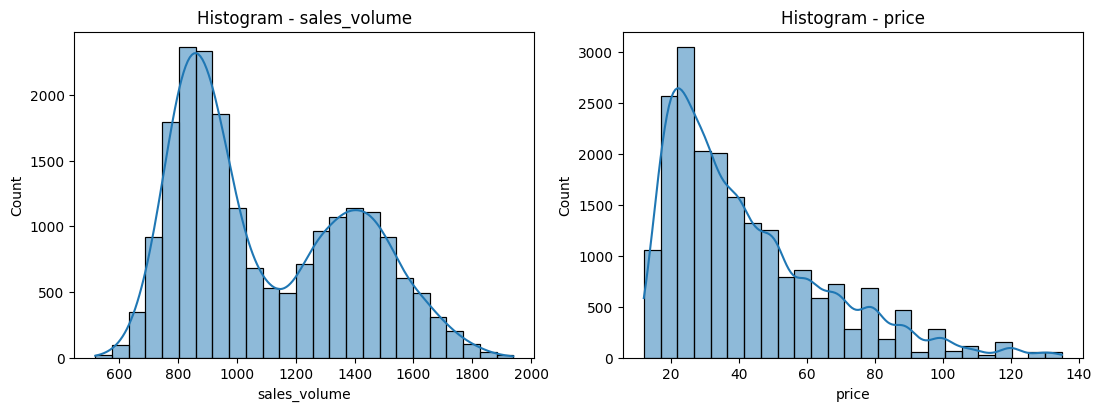

In [15]:
fig, axes = sub_plot(num_columns)

for index, col in enumerate(num_columns):
    sns.histplot(sales_df[col], bins = 25, kde = True, ax = axes[index])
    axes[index].set_title(f"Histogram - {col}")
    axes[index].set_xlabel(col)
    axes[index].set_ylabel("Count")

for j in range(index + 1, len(axes)):
    axes[j].set_visible(False)


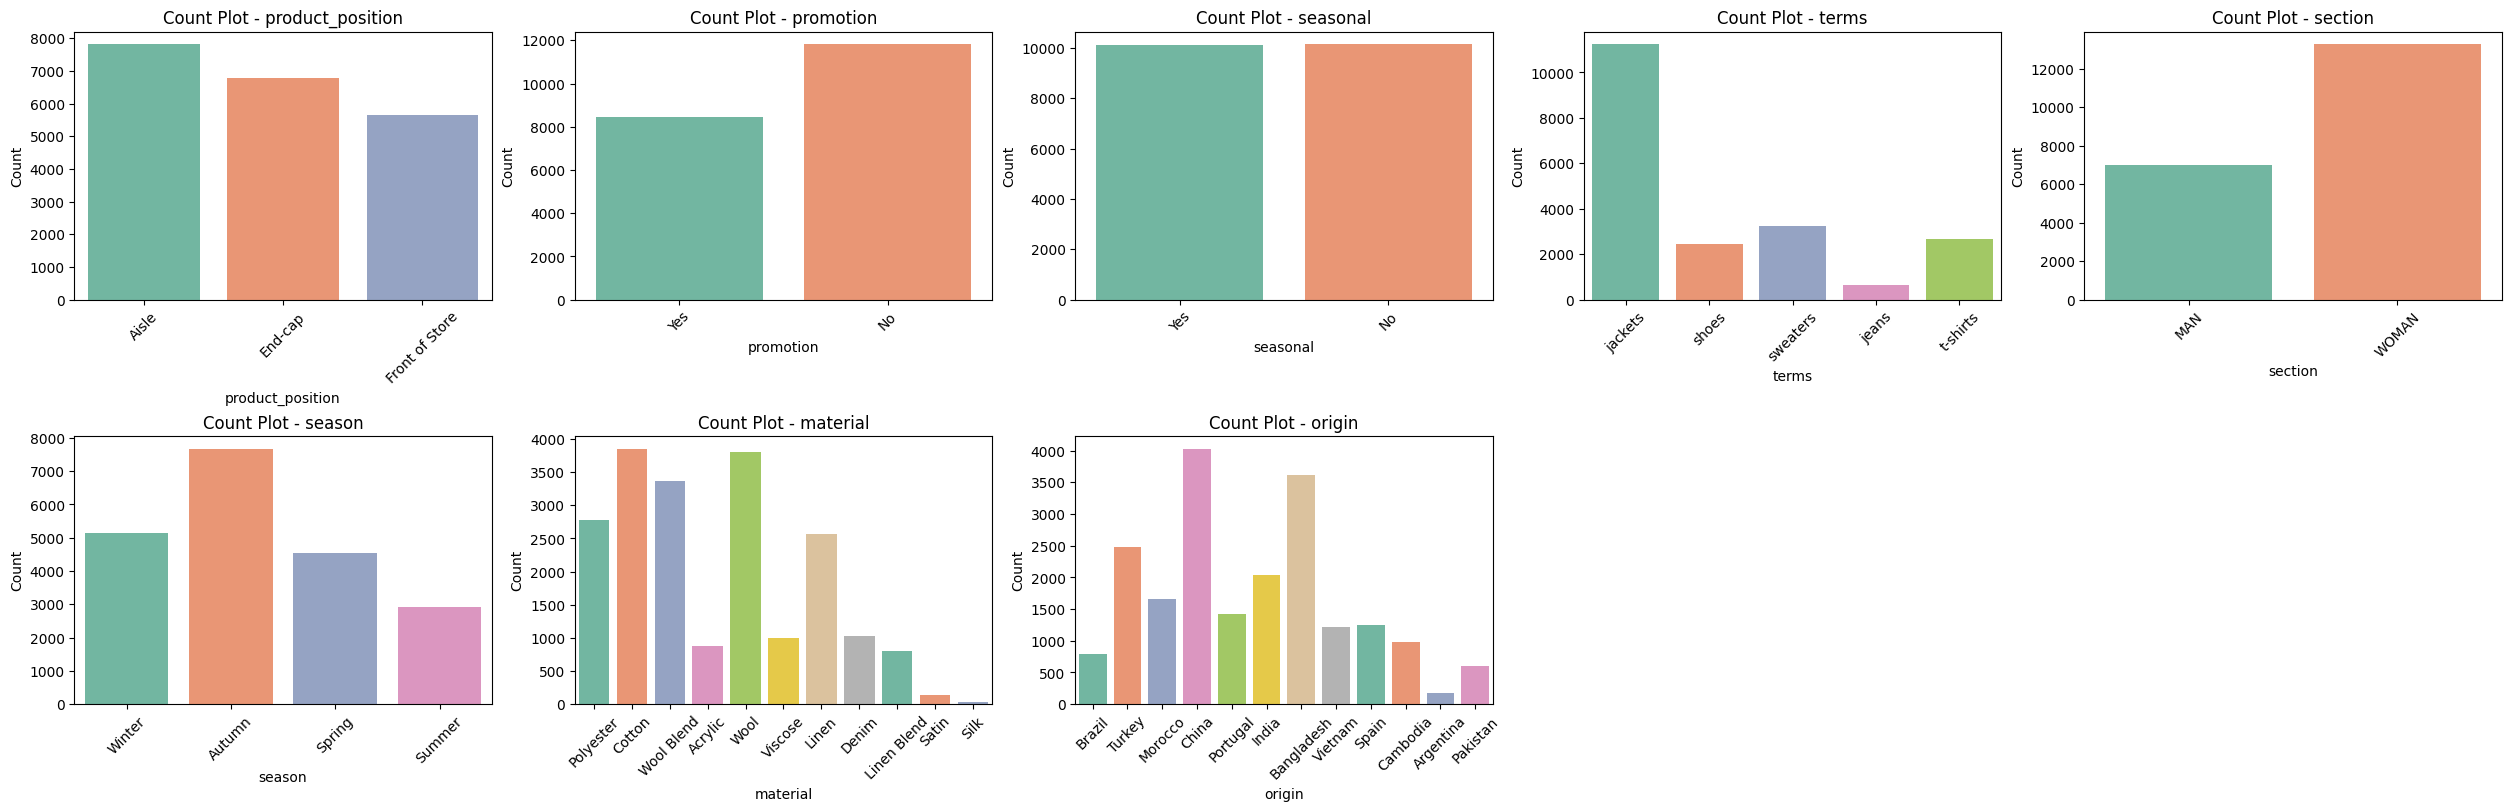

In [16]:
fig, axes = sub_plot(cat_columns)

for index, col in enumerate(cat_columns):
    sns.countplot(x = col, data = sales_df, ax = axes[index], palette = 'Set2',  
                  hue = col, legend = False)
    axes[index].tick_params(axis = 'x', rotation = 45)
    axes[index].set_title(f"Count Plot - {col}")
    axes[index].set_xlabel(col)
    axes[index].set_ylabel("Count")

for j in range(index + 1, len(axes)):
    axes[j].set_visible(False)

Text(0.5, 1.0, 'Comparison of terms and section')

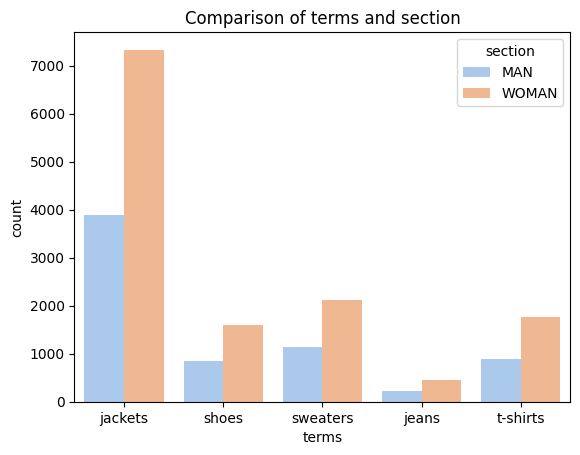

In [17]:
cat1 = 'terms'
cat2 = 'section'

sns.countplot(data = sales_df, x = cat1, hue = cat2, palette = 'pastel')
plt.title(f"Comparison of {cat1} and {cat2}")

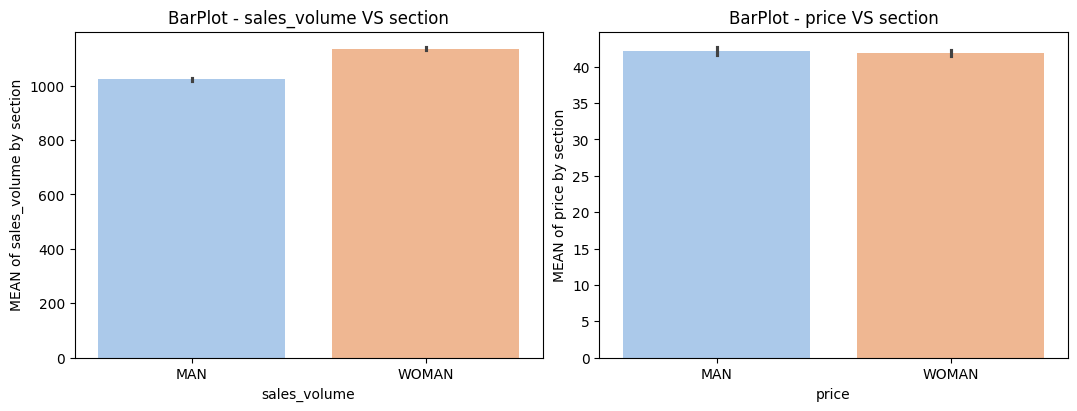

In [18]:
fig, axes = sub_plot(num_columns)
for i, col in enumerate(num_columns):
    sns.barplot(data = sales_df, x = "section", y = col, ax = axes[i], palette = "pastel", hue = "section", legend = False)
    axes[i].set_title(f"BarPlot - {col} VS section")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(f'MEAN of {col} by section')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

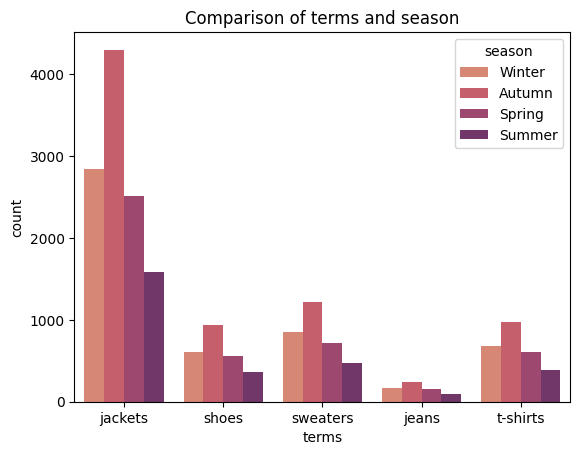

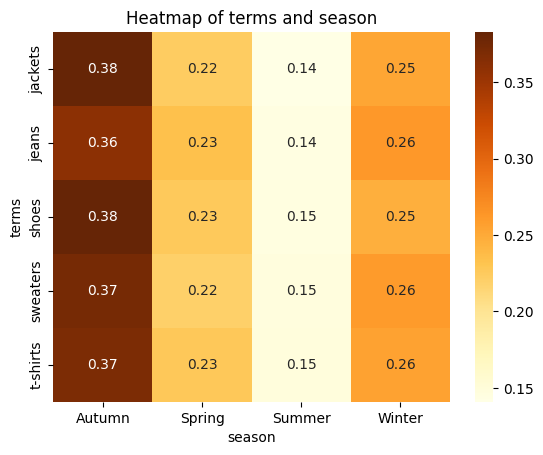

In [19]:
cat1 = 'terms'
cat2 = 'season'

sns.countplot(data = sales_df, x = cat1, hue = cat2, palette = "flare")
plt.title(f"Comparison of {cat1} and {cat2}")
plt.show()

ct = pd.crosstab(sales_df[cat1], sales_df[cat2], normalize='index')
sns.heatmap(ct, annot = True, cmap = "YlOrBr")
plt.title(f"Heatmap of {cat1} and {cat2}");

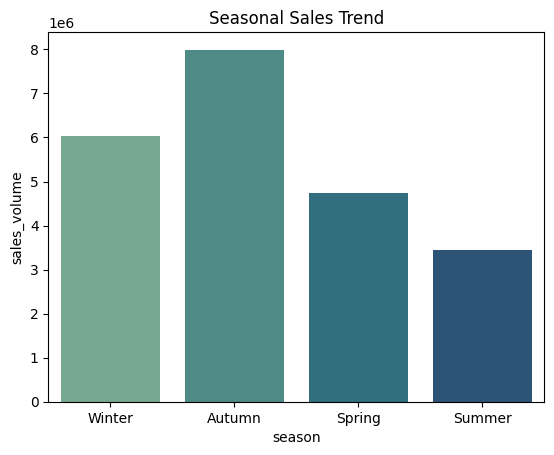

In [20]:
cat1 = 'season'
cat2 = 'sales_volume'
sns.barplot(data = sales_df, x = cat1, y = cat2, estimator = np.sum, errorbar = None, palette = 'crest', hue = cat1, legend = False)
plt.title("Seasonal Sales Trend")
plt.xlabel(cat1)
plt.ylabel(cat2);

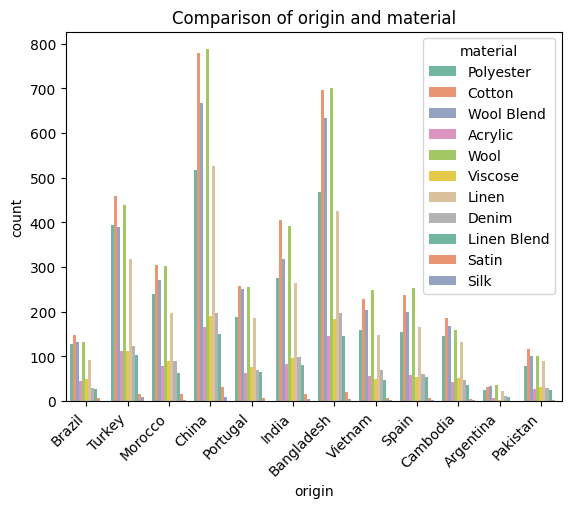

In [21]:
cat1 = 'origin'
cat2 = 'material'

sns.countplot(data = sales_df, x = cat1, hue = cat2, palette = "Set2")
plt.xticks(rotation = 45, ha = 'right')
plt.title(f"Comparison of {cat1} and {cat2}");

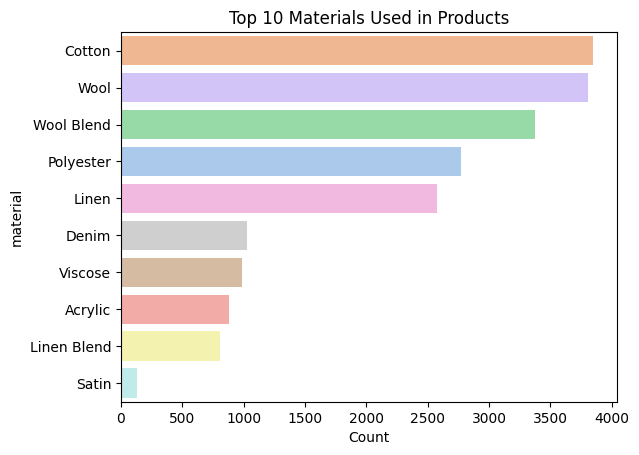

In [22]:
cat1 = "material"

sns.countplot(data = sales_df, y = cat1, order = sales_df['material'].value_counts().head(10).index, palette = "pastel", hue = cat1, legend = False)
plt.title("Top 10 Materials Used in Products")
plt.xlabel("Count")
plt.ylabel(f"{cat1}");

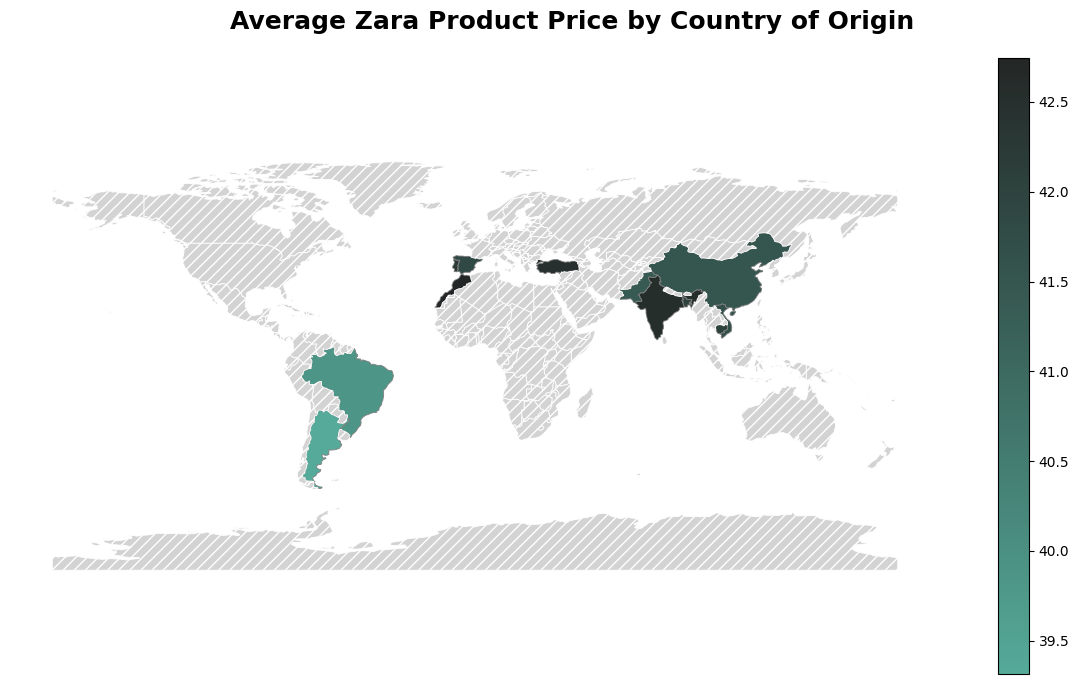

In [ ]:

url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
gdf = gpd.read_file(url)


country_avg = (
    sales_df.groupby('origin')
    .agg(
        count_products = ('origin', 'size'),
        avg_price = ('price', 'mean')
    )
    .reset_index()
    .rename(columns = {'origin': 'Country'})
)

world = gpd.read_file(url)

merged = world.merge(country_avg, how = "left", left_on = "NAME", right_on = "Country")

fig, ax = plt.subplots(figsize = (15, 8))

colors = sns.color_palette("dark:#5A9_r", as_cmap=True)

merged.plot(
    column = 'avg_price',
    cmap = colors,      
    linewidth = 0.6,
    edgecolor = 'gray',
    legend = True,
    ax = ax,
    missing_kwds = {
        "color": "lightgrey",  
        "edgecolor": "white",
        "hatch": "///",
        "label": "No data"
    }
)

ax.set_axis_off()
plt.suptitle(
    "Average Zara Product Price by Country of Origin",
    fontsize = 18,
    fontweight = 'bold',
    y = 0.94
);
